# 04 — Communities (Course topic L5)

**Semiconductor Supply Chain — Network Analysis**

Does the supply network break into natural clusters? We run **Louvain** community
detection on the weighted undirected `SUPPLIES` graph and then ask the key
question: do firms cluster by **tier** (what they make) or by **geography**
(where they are)?

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'scripts' / 'analysis.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import analysis

D = analysis.company_supply_digraph()
U = D.to_undirected(as_view=False)
print(f'{U.number_of_nodes()} companies, {U.number_of_edges()} undirected SUPPLIES links')

108 companies, 1256 undirected SUPPLIES links


## 1. Louvain communities

In [2]:
comms = nx.community.louvain_communities(U, weight='weight', seed=42)
comms = sorted(comms, key=len, reverse=True)
part = {n: i for i, c in enumerate(comms) for n in c}
Q = nx.community.modularity(U, comms, weight='weight')
print(f'{len(comms)} communities, modularity Q = {Q:.3f}')
for i, c in enumerate(comms):
    print(f'  community {i}: {len(c):3d} firms')

3 communities, modularity Q = 0.220
  community 0:  60 firms
  community 1:  25 firms
  community 2:  23 firms


## 2. Community composition — tier vs. region

If communities line up with **tier**, the columns of the tier crosstab will be
concentrated; if with **region**, the region crosstab will be.

In [3]:
df = pd.DataFrame({
    'community': pd.Series(part),
    'type': pd.Series(dict(U.nodes(data='type'))),
    'region': pd.Series(dict(U.nodes(data='region'))),
    'country': pd.Series(dict(U.nodes(data='country'))),
})
print('Community x tier'); display(pd.crosstab(df['community'], df['type']))
print('Community x region'); display(pd.crosstab(df['community'], df['region']))

Community x tier


type,EDA,EMS,IDM,IP,equipment,fab,fabless,gases,materials,photomask,substrate,subsystem
community,,,,,,,,,,,,
0,0,0,16,0,11,8,0,5,14,2,0,4
1,0,9,0,0,4,0,5,0,2,0,5,0
2,3,0,1,4,1,2,11,0,0,1,0,0


Community x region


region,Asia,Europe,Middle East,North America
community,,,,
0,29,12,1,18
1,16,2,0,7
2,8,2,0,13


In [4]:
for i, c in enumerate(comms):
    sub = df.loc[sorted(c)]
    top_type = sub['type'].mode().iat[0]
    top_region = sub['region'].mode().iat[0]
    members = ', '.join(sorted(c)[:6])
    print(f'community {i} ({len(c):3d}): mostly {top_type:9s} / {top_region:13s} — e.g. {members}')

community 0 ( 60): mostly IDM       / Asia          — e.g. ASM International, ASML, Air Liquide, Air Products, Analog Devices, Applied Materials
community 1 ( 25): mostly EMS       / Asia          — e.g. AMD, ASE Group, AT&S, Advantest, Ajinomoto, Amkor
community 2 ( 23): mostly fabless   / North America — e.g. ARM, Amazon, Ambarella, Cadence, Cerebras, Ceva


## 3. Tier or geography? Compare modularities

We score two *fixed* partitions — one by tier, one by region — with the same
modularity function. A **negative** modularity means members of that group are
*less* connected to each other than chance (an anti-community); a positive value
means they cluster. Comparing both to Louvain's Q tells us what really organises
the network.

In [5]:
def partition_from(attr):
    groups = {}
    for n, v in U.nodes(data=attr):
        groups.setdefault(v, set()).add(n)
    return list(groups.values())

Q_type = nx.community.modularity(U, partition_from('type'), weight='weight')
Q_region = nx.community.modularity(U, partition_from('region'), weight='weight')
print(f'modularity by Louvain : {Q:.3f}')
print(f'modularity by tier    : {Q_type:.3f}')
print(f'modularity by region  : {Q_region:.3f}')

modularity by Louvain : 0.220
modularity by tier    : -0.151
modularity by region  : 0.030


## 4. Visualise — coloured by Louvain community

saved

 C:\Users\Max\Desktop\project\reports\figures\04_communities.png


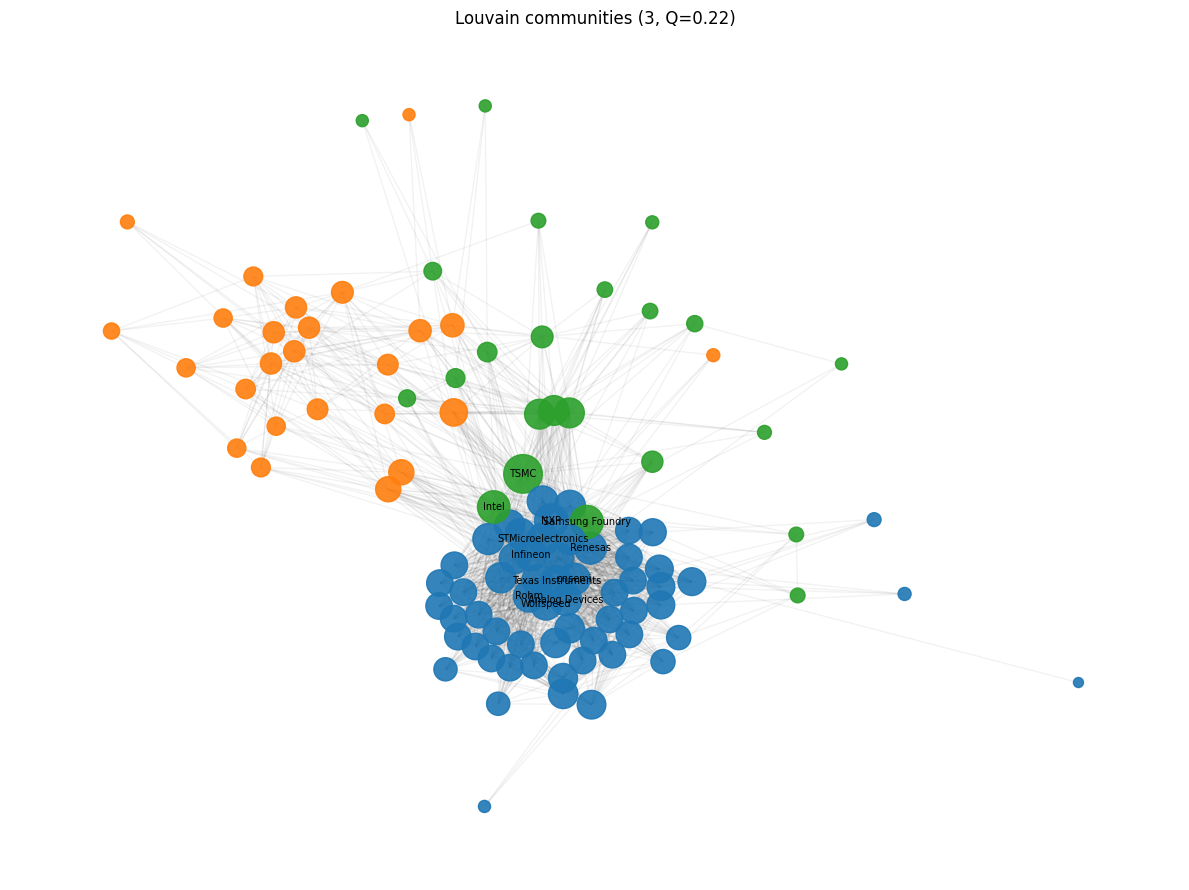

In [6]:
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(U, seed=42, k=0.30)
palette = cm.tab10(np.linspace(0, 1, max(10, len(comms))))
colors = [palette[part[n]] for n in U.nodes()]
sizes = [40 + 12 * U.degree(n) for n in U.nodes()]
nx.draw_networkx_edges(U, pos, alpha=0.05, ax=ax)
nx.draw_networkx_nodes(U, pos, node_color=colors, node_size=sizes, alpha=0.9, ax=ax)
top_deg = sorted(U.nodes(), key=lambda n: U.degree(n), reverse=True)[:12]
nx.draw_networkx_labels(U, pos, labels={n: n for n in top_deg}, font_size=7, ax=ax)
ax.set_title(f'Louvain communities ({len(comms)}, Q={Q:.2f})'); ax.axis('off')
fig.tight_layout()
out = analysis.FIGURES / '04_communities.png'
fig.savefig(out, dpi=130, bbox_inches='tight'); print('saved', out); plt.show()

## 5. Takeaways

- Louvain finds only **3 communities** with **modest** modularity (Q ≈ 0.22) —
  the network is densely cross-linked, so it does not split cleanly.
- **Tier is *anti*-modular** (Q_tier ≈ −0.15): firms in the same tier barely
  supply *each other*. That negative value is the fingerprint of a **multipartite**
  supply chain — links run *across* tiers (equipment→fab→fabless), not within.
- **Geography is only weakly modular** (Q_region ≈ 0.03): supply links are global
  (Japanese materials → Taiwanese fabs → US fabless), so country is *not* a strong
  clustering axis either.
- The Louvain communities are therefore **cross-tier supply clusters** — a hub
  plus its up- and downstream partners (e.g. a TSMC-centred cluster spanning
  equipment, materials and fabless) — rather than tier blocks or country blocks.
  Geography still matters for *risk* (see the enrichment political-risk scores),
  just not for *clustering*.

**Next:** `05_models_comparison.ipynb` — compare against an Erdős–Rényi baseline
and test the small-world property.